# Deep Learning for Trading Signal Construction

This notebook demonstrates the use of deep learning to construct trading signals from real limit order book (LOB) data. The focus is on practical steps relevant to quantitative trading: data loading, feature engineering, model training, and evaluation.

In [1]:
# Load limit order book data from CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Data Loading and Preparation
This section loads the limit order book data from a CSV file and assigns descriptive column names for easier analysis. The data includes price and volume information for multiple levels of the order book, which will be used for feature engineering and model training.

In [2]:
data_dir = Path('../data/')

# Read Data_A csv file into pandas DataFrame
file_path = data_dir / 'Data_A.csv'

data = pd.read_csv(file_path, header=None)

# Add names to the columns for easier identification
data.columns=["label","askl1","vola1","bidl1","volb1","askl2",
            "vola2","bidl2","volb2","askl3","vola3","bidl3","volb3",
            "askl4","vola4","bidl4","volb4",
            "m1","m2","m3","m4","m5"]

## Splitting Data into Training and Validation Sets
To prepare for model training, we split the dataset into features (`x_train_full`) and labels (`y_train_full`). We then divide the data into training and validation sets using an index, ensuring that the model can be evaluated on unseen data to assess its generalization performance. This step is crucial for preventing overfitting and for reliable model validation.

In [6]:
# Split data into features and labels, then into training and validation sets
x_train_full = data.drop("label", axis=1)
y_train_full = np.array(data["label"])

# Index for splitting between training and validation data
split_ind = 80000

# Training and validation split
x_train = x_train_full[:split_ind]
y_train = y_train_full[:split_ind]
x_val = x_train_full[split_ind:]
y_val = y_train_full[split_ind:]

## Feature Normalization
To ensure efficient and stable training of the neural network, we normalize all features to similar scales. This is done by computing the mean and standard deviation from the training set and applying the same transformation to both training and validation data. Normalization helps the model converge faster and improves overall performance.

In [7]:
# Normalize features: compute means and standard deviations from training data
means = x_train.mean(0)
stds = x_train.std(0)

# Apply normalization to training and validation sets
x_train = (x_train - means) / stds
x_val = (x_val - means) / stds

## Building and Training the Neural Network
With the data prepared and normalized, we are ready to build and train our first deep neural network for trading signal prediction. Setting a random seed ensures that results are reproducible, which is important for both research and production environments.

In [20]:
# Build and train a practical deep neural network for trading signal prediction
import tensorflow.keras as keras  # Import Keras for deep learning

keras.utils.set_random_seed(125)

# Define the neural network architecture
f = keras.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=(x_train.shape[1],)),  # First hidden layer
    keras.layers.Dense(200, activation="relu"),  # Second hidden layer
    keras.layers.Dense(1, activation="sigmoid")  # Output layer for binary classification
])

# Set learning rate and compile the model with Adam optimizer and binary cross-entropy loss
learning_rate = 0.1
f.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
          loss="binary_crossentropy", metrics=["accuracy"])

# Train the model on the training set and validate on the validation set
history = f.fit(x_train, y_train, epochs=40, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/40


c:\Users\pmpls\Desktop\Universidad\Proyectos Curriculum\Next Tick Prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6390 - loss: 0.6735 - val_accuracy: 0.6499 - val_loss: 0.6171
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6390 - loss: 0.6735 - val_accuracy: 0.6499 - val_loss: 0.6171
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6542 - loss: 0.6150 - val_accuracy: 0.6604 - val_loss: 0.6104
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6542 - loss: 0.6150 - val_accuracy: 0.6604 - val_loss: 0.6104
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6615 - loss: 0.6076 - val_accuracy: 0.6695 - val_loss: 0.6043
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6615 - loss: 0.6076 - val_accuracy: 0.6695 - val_loss: 0.6043
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6598 - loss: 0.6100 - val_accuracy: 0.6644 - val_loss: 0.6119
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6598 - loss: 0.6100 - val_accuracy: 0.6644 - val_

## Evaluating the Baseline Model
After training the baseline neural network, we evaluate its performance on the validation set. The validation accuracy provides a measure of how well the model generalizes to unseen data and serves as a reference point for further model improvements.

In [21]:
# Evaluate the baseline model on the validation set
pred = f.predict(x_val, verbose=0)  # Get predicted probabilities for validation data
pred_labels = [int(prob > 0.5) for prob in pred]  # Convert probabilities to binary labels
accuracy = np.mean(np.array(pred_labels) == y_val)  # Calculate validation accuracy
print(f"Validation accuracy: {accuracy:.4f}")

Validation accuracy: 0.5041


C:\Users\pmpls\AppData\Local\Temp\ipykernel_16812\3161448364.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_labels = [int(prob > 0.5) for prob in pred]  # Convert probabilities to binary labels


## Visualizing Model Training Progress
After evaluating the baseline model, it's important to understand how the training process evolves over time. Visualizing training and validation metrics helps us diagnose issues such as overfitting, underfitting, or unstable learning.

Here, we introduce a customized plotting function to visually examine how training has progressed:
- **Training loss and accuracy:** Show how well the model fits the training data over epochs.
- **Validation loss and accuracy:** Indicate how well the model generalizes to unseen data.

**Why use custom plots?**
- Custom visualizations make it easier to communicate model performance and training dynamics to both technical and non-technical audiences.
- They help identify problems early, such as overfitting, poor convergence, or the need for hyperparameter tuning.
- Visual feedback is essential for iterative model improvement and for presenting results in research or production settings.

In [22]:
# Custom function to plot training and validation loss/accuracy
def training_plot(history):
    # Create a figure with two subplots: one for loss, one for accuracy
    plt.figure(figsize=(14, 6))

    # --- Plot training and validation loss ---
    plt.subplot(1, 2, 1)  # First subplot (left)
    loss = history.history["loss"]  # Training loss per epoch
    val_loss = history.history["val_loss"]  # Validation loss per epoch
    epochs = range(1, len(loss) + 1)  # Epoch numbers
    plt.plot(epochs, loss, "b-", label="Training loss")  # Plot training loss
    plt.plot(epochs, val_loss, "g-", label="Validation loss")  # Plot validation loss
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # --- Plot training and validation accuracy ---
    plt.subplot(1, 2, 2)  # Second subplot (right)
    acc = history.history["accuracy"]  # Training accuracy per epoch
    val_acc = history.history["val_accuracy"]  # Validation accuracy per epoch
    epochs = range(1, len(acc) + 1)  # Epoch numbers
    plt.plot(epochs, acc, "b-", label="Training accuracy")  # Plot training accuracy
    plt.plot(epochs, val_acc, "g-", label="Validation accuracy")  # Plot validation accuracy
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Show the plots
    plt.show()

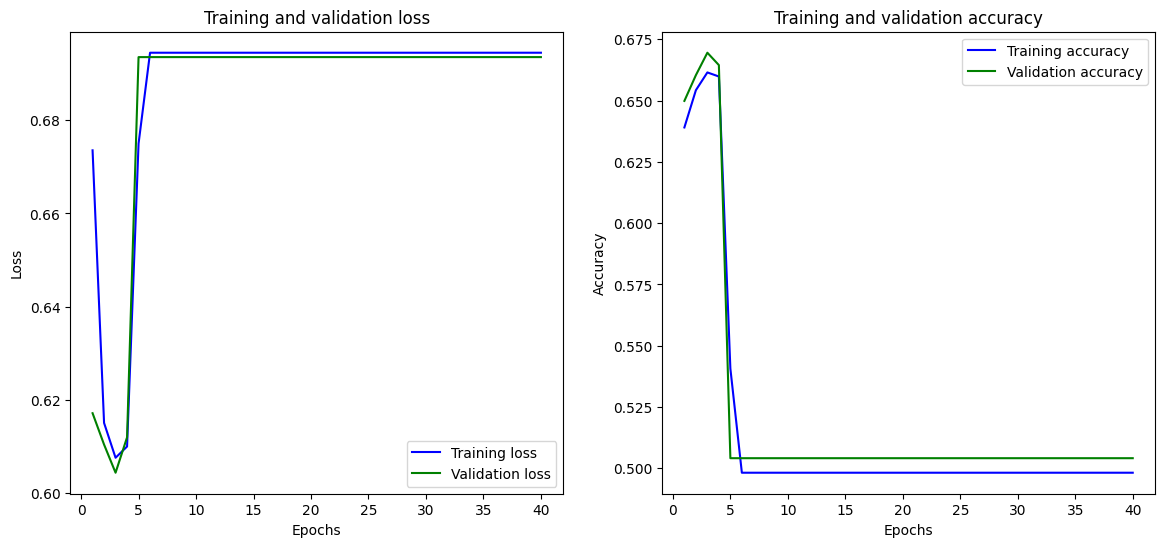

In [23]:
# Plot the training history
training_plot(history)

## Diagnosing and Tuning Learning Rate
After visualizing the training progress, we notice that the training process is noisy and unstable. This often suggests that the learning rate may be set too high, causing the optimizer to overshoot minima and preventing smooth convergence.

### Why adjust the learning rate?
- The learning rate controls how much the model weights are updated during training. If it's too high, training can be unstable; if too low, convergence can be slow.
- Proper tuning of the learning rate is essential for achieving optimal model performance and stability.

### Next step:
We will decrease the learning rate and retrain the model to observe if training and validation metrics become smoother and more stable. This is a common and effective strategy in deep learning workflows.

In [24]:
# Tune learning rate and retrain model to improve stability
keras.utils.set_random_seed(125)  # Set random seed for reproducibility

# Define the neural network architecture (same as before)
f = keras.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=(x_train.shape[1],)),  # First hidden layer
    keras.layers.Dense(200, activation="relu"),  # Second hidden layer
    keras.layers.Dense(1, activation="sigmoid")  # Output layer for binary classification
])

# Lower the learning rate to improve training stability
learning_rate = 0.001
f.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
          loss="binary_crossentropy", metrics=["accuracy"])

# Retrain the model with the new learning rate and observe the results
history = f.fit(x_train, y_train, epochs=40, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/40


c:\Users\pmpls\Desktop\Universidad\Proyectos Curriculum\Next Tick Prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7210 - loss: 0.5470 - val_accuracy: 0.7526 - val_loss: 0.4978
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7210 - loss: 0.5470 - val_accuracy: 0.7526 - val_loss: 0.4978
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7538 - loss: 0.4929 - val_accuracy: 0.7574 - val_loss: 0.4847
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7538 - loss: 0.4929 - val_accuracy: 0.7574 - val_loss: 0.4847
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7576 - loss: 0.4855 - val_accuracy: 0.7594 - val_loss: 0.4816
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7576 - loss: 0.4855 - val_accuracy: 0.7594 - val_loss: 0.4816
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7586 - loss: 0.4821 - val_accuracy: 0.7624 - val_loss: 0.4801
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7586 - loss: 0.4821 - val_accuracy: 0.7624 - val_

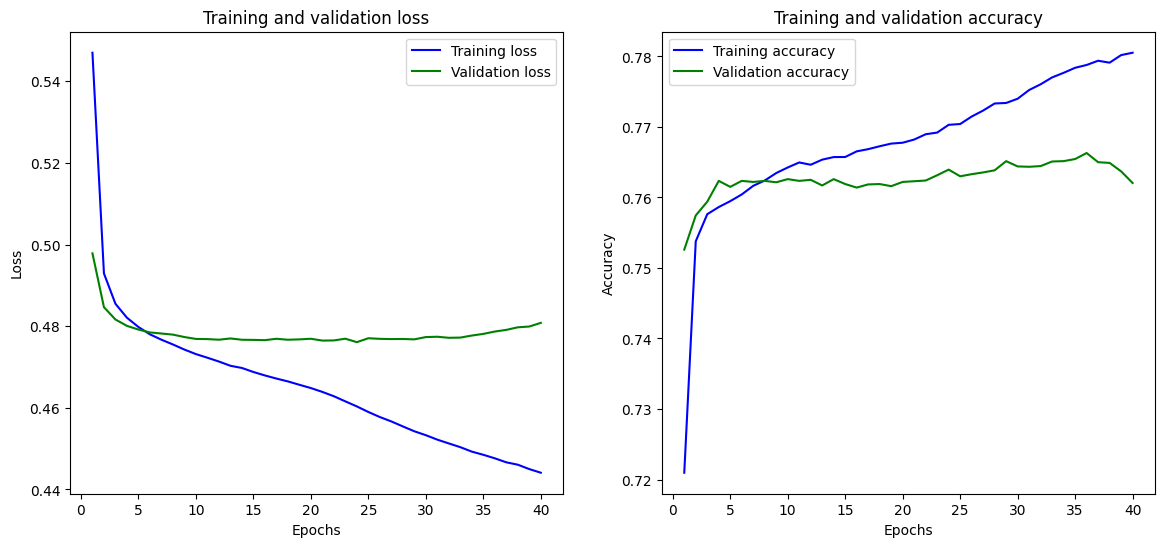

In [25]:
# Plot the training history
training_plot(history)

In [26]:
# Return the validation accuracy.
pred = f.predict(x_val,verbose = 0)
pred = [int(prob>0.5) for prob in pred]
res = [int(pred[i]==y_val[i]) for i in range(len(y_val))]
print(f"The validation accuracy is: {sum(res)/len(res)}")

The validation accuracy is: 0.76205


C:\Users\pmpls\AppData\Local\Temp\ipykernel_16812\3781929734.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred = [int(prob>0.5) for prob in pred]


## Impact of Learning Rate Tuning
After lowering the learning rate and retraining, we observe that the training process has become more stable and the validation accuracy has improved. This demonstrates the importance of hyperparameter tuning in deep learning.

### Why does learning rate matter?
- The learning rate determines how quickly the model adapts to the data. A well-chosen learning rate helps the optimizer find a good solution efficiently, while a poor choice can lead to instability or slow convergence.
- Tuning the learning rate is often one of the most effective ways to improve model performance and training dynamics.

### Broader context
- Hyperparameter tuning, including learning rate adjustment, is a key skill for building high-performing models.
- It is an iterative process: try different values, observe results, and refine your choices based on validation performance.

## Recognizing and Addressing Overfitting
From the training and validation curves, we observe that after a certain point, the model's performance on the training set continues to improve while its performance on the validation set stagnates or worsens. This is a classic sign of overfitting.

### What is overfitting?
- Overfitting occurs when a model learns patterns specific to the training data, including noise, rather than generalizable features.
- As a result, the model performs well on training data but poorly on new, unseen data.

### How can we address overfitting?
There are several strategies to combat overfitting:
- **Introduce a dropout layer:** Randomly deactivate neurons during training to force the network to learn more robust features.
- **Stop training earlier:** Use early stopping to halt training when validation performance stops improving.
- **Other techniques:** Regularization, data augmentation, and reducing model complexity.

**Why is this important?**
- Addressing overfitting is essential for building models that generalize well and are reliable in production or real-world scenarios.

In [27]:
# Improved Model: Add Dropout Layers to Reduce Overfitting
keras.utils.set_random_seed(125)  # Set random seed for reproducibility

# Define a neural network architecture with dropout layers for regularization
f = keras.Sequential([
    keras.layers.Dense(100, activation="relu", input_shape=(x_train.shape[1],)),  # First hidden layer
    keras.layers.Dropout(0.2),  # Dropout layer to reduce overfitting (20% dropout)
    keras.layers.Dense(200, activation="relu"),  # Second hidden layer
    keras.layers.Dropout(0.2),  # Another dropout layer (20% dropout)
    keras.layers.Dense(1, activation="sigmoid")  # Output layer for binary classification
])

c:\Users\pmpls\Desktop\Universidad\Proyectos Curriculum\Next Tick Prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Visualize the network with dropout layers

**Why visualize dropout?**
- Visualizing the architecture, including dropout layers, helps communicate the model's regularization strategy and design choices.

In [28]:
# Training works as before.
learning_rate = 0.001
f.compile(optimizer=keras.optimizers.Adam(
    learning_rate=learning_rate),loss="binary_crossentropy",metrics=["accuracy"])
history = f.fit(x_train,y_train,epochs=40,batch_size=128,validation_data=(x_val,y_val))

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6993 - loss: 0.5757 - val_accuracy: 0.7566 - val_loss: 0.4990
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6993 - loss: 0.5757 - val_accuracy: 0.7566 - val_loss: 0.4990
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7485 - loss: 0.5070 - val_accuracy: 0.7602 - val_loss: 0.4863
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7485 - loss: 0.5070 - val_accuracy: 0.7602 - val_loss: 0.4863
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7542 - loss: 0.4951 - val_accuracy: 0.7602 - val_loss: 0.4834
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7542 - loss: 0.4951 - val_accuracy: 0.7602 - val_loss: 0.4834
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7558 - loss: 0.4897 - val_accuracy: 0.7597 - val_loss: 0.4802
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7558 - loss: 0.4897 - val_accuracy: 0.

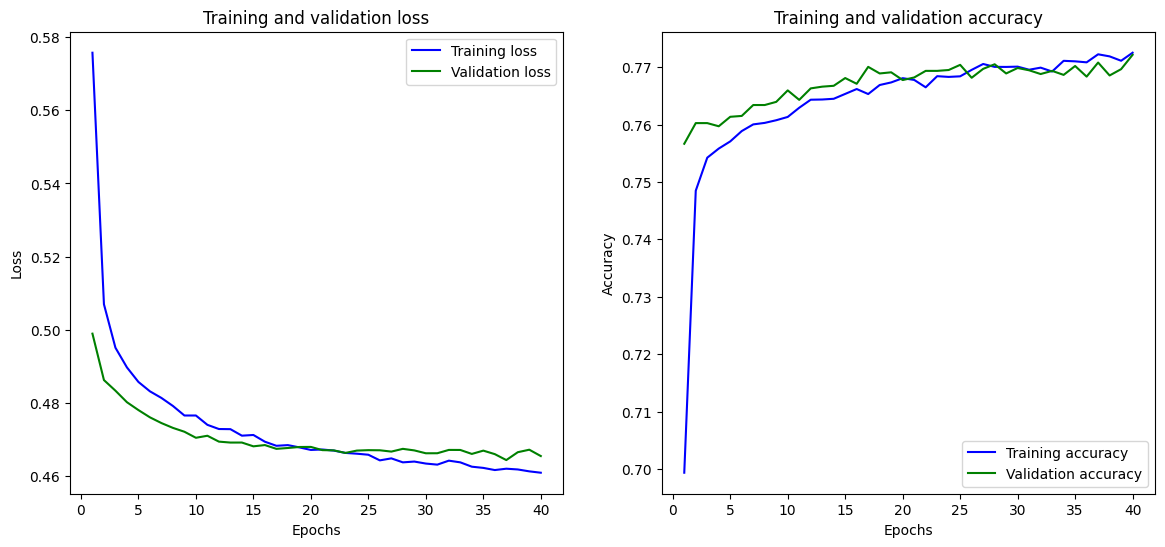

In [29]:
# Plot the training history
training_plot(history)

In [30]:
# Evaluate validation accuracy for the dropout model
pred = f.predict(x_val, verbose=0)
pred_labels = [int(prob > 0.5) for prob in pred]
accuracy = np.mean(np.array(pred_labels) == y_val)
print(f"Validation accuracy (dropout model): {accuracy:.4f}")

Validation accuracy (dropout model): 0.7722


C:\Users\pmpls\AppData\Local\Temp\ipykernel_16812\3860575028.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_labels = [int(prob > 0.5) for prob in pred]


We see that we have been able to further improve the validation accuracy. Most of the overfitting has been mitigated.

## Ideas for Improving Validation Accuracy
If you want to further improve your model's validation accuracy, consider experimenting with the following strategies:

- **Feature selection:** Identify and use only the most relevant features to reduce noise and improve generalization.
- **Learning rate tuning:** Try different learning rates to find the optimal value for stable and efficient training.
- **Activation function choice:** Experiment with different activation functions (e.g., ReLU, Leaky ReLU, ELU) to see which works best for your data.
- **Number of layers:** Adjust the depth of your neural network to balance model complexity and generalization.
- **Dropout layers:** Add or modify dropout layers to further reduce overfitting.
- **Batch normalization layers:** Incorporate batch normalization to stabilize and accelerate training.

**Why experiment?**
- Iterative experimentation and testing are essential for discovering the best model configuration and achieving high performance in machine learning projects.

## Out-of-Sample Evaluation: Testing Model Robustness
Now that we have tuned and validated our model, it's time to assess its true robustness by evaluating it on completely unseen data. This step uses a separate test set (Data_B.csv) that was not used during training or validation.

### Why perform out-of-sample evaluation?
- Out-of-sample testing provides a realistic measure of how well the model will perform in real-world scenarios, especially in financial applications where data distributions can shift.
- It helps detect overfitting and ensures that the model's performance is not just due to memorizing the training data.

### What happens in the next cell?
- We load the test data and assign column names for consistency.
- Features are normalized using the statistics from the training set (never the test set itself).
- The trained model predicts labels for the test data.
- We calculate and print the out-of-sample accuracy, which is the key metric for model generalization.

A strong out-of-sample accuracy indicates that the model is robust and ready for deployment or further analysis.

In [32]:
# Load and preprocess test data for out-of-sample evaluation
file_path = data_dir / 'Data_B.csv'  # Path to out-of-sample test data
df_test = pd.read_csv(file_path, header=None)  # Load test data into DataFrame
df_test.columns = [
    "label", "askl1", "vola1", "bidl1", "volb1", "askl2", "vola2", "bidl2", "volb2",
    "askl3", "vola3", "bidl3", "volb3", "askl4", "vola4", "bidl4", "volb4",
    "m1", "m2", "m3", "m4", "m5"
    ]  # Assign column names for consistency

# Split into features and labels
x_test = df_test.drop("label", axis=1)  # Features for prediction
y_test = np.array(df_test["label"])    # True labels

# Normalize test features using training set statistics
x_test = (x_test - means) / stds  # Apply training normalization to test data

# Evaluate out-of-sample accuracy
pred_test = f.predict(x_test, verbose=0)  # Predict probabilities for test data
pred_test_labels = [int(prob > 0.5) for prob in pred_test]  # Convert probabilities to binary labels
test_accuracy = np.mean(np.array(pred_test_labels) == y_test)  # Calculate test accuracy
print(f"Out-of-sample accuracy: {test_accuracy:.4f}")  # Display out-of-sample accuracy

Out-of-sample accuracy: 0.7733


C:\Users\pmpls\AppData\Local\Temp\ipykernel_16812\3046733615.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_test_labels = [int(prob > 0.5) for prob in pred_test]  # Convert probabilities to binary labels


#### Comparison with Logistic Regression Results
- Test Accuracy of Linear Model:  0.7169
- Test Accuracy of Quadratic Model:  0.7339

#### Deep Learning Model Result
- Test Accuracy of Deep Learning Model:  0.7733

**Conclusion:**
The deep learning model achieves a higher out-of-sample accuracy (0.7733) compared to both the linear (0.7169) and quadratic (0.7339) logistic regression models. This demonstrates the advantage of using deep neural networks for capturing complex patterns in limit order book data.